## Setup

**Test date: 1.5.2026**

**Claude Sonnet 4.6** was tasked with generating a **couch** using the **SPOMSO** package. Claude was provided with the [spomso_sdf_guide](./guides/spomso_sdf_guide.md) file and the following prompt:

*Read through the attached .md file. It contains a guide how to use the Python package SPOMSO. I want you to design a couch using this Python package. As the output I want some code that I would run and it would output the point cloud of the object and some figures. Make sure that the resulting plots show true proportions of the object. Everything else I leave up to you. Good luck and if you have any questions feel free to ask.*

## Response:

Now I have a thorough understanding of the API. Let me design a detailed couch!It ran perfectly — 75,722 surface points. Let me copy the outputs and present them.Here's what was built! The couch is composed of **14 SDF primitives** unioned together:

| Part | Shape | Details |
|---|---|---|
| Base frame | `Box` + rounding | low slab tying everything together |
| 4 × legs | `Cylinder` + rounding | tapered round legs at the corners |
| Seat platform | `Box` + rounding | structural foam base under the cushions |
| 3 × seat cushions | `Box` + heavy rounding | side-by-side, puffy with `r=0.055` |
| Back rest slab | `Box` + rounding + 8° tilt | structural back, slightly reclined |
| 3 × back cushions | `Box` + rounding + 8° tilt | aligned with the back slab |
| 2 × arm rests | `Box` + rounding | wide, rounded arms on each side |

The grid is set to `130 × 65 × 60` voxels over a `2.6 × 1.3 × 1.2 m` volume (~2 cm per voxel), and all three orthographic views use `aspect="equal"` with axes sized proportionally to the physical dimensions — so what you see is truly to scale. The point cloud came out to **75,722 surface points**.

Evaluating SDF on grid …
Done.
Point cloud: 75,722 points → couch_surface.npy
Saved → couch_views.png
Saved → couch_pointcloud.png


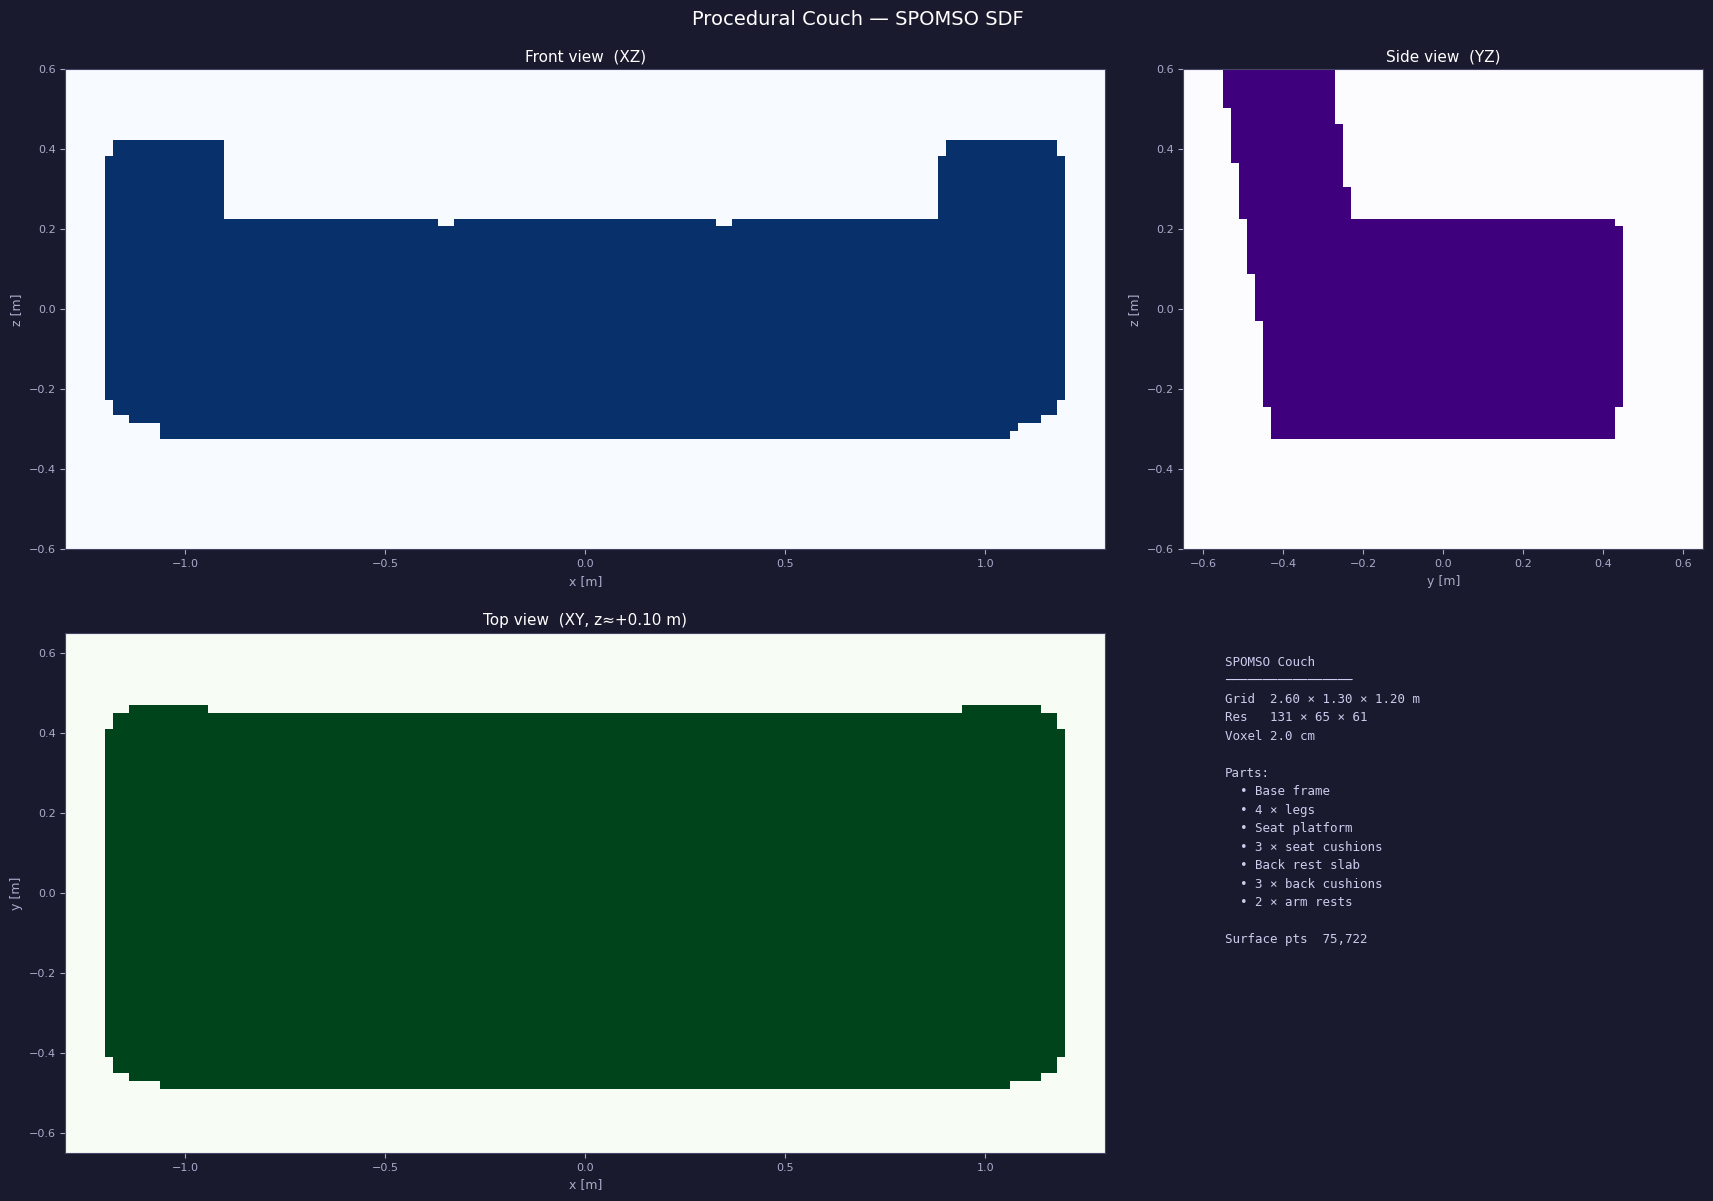

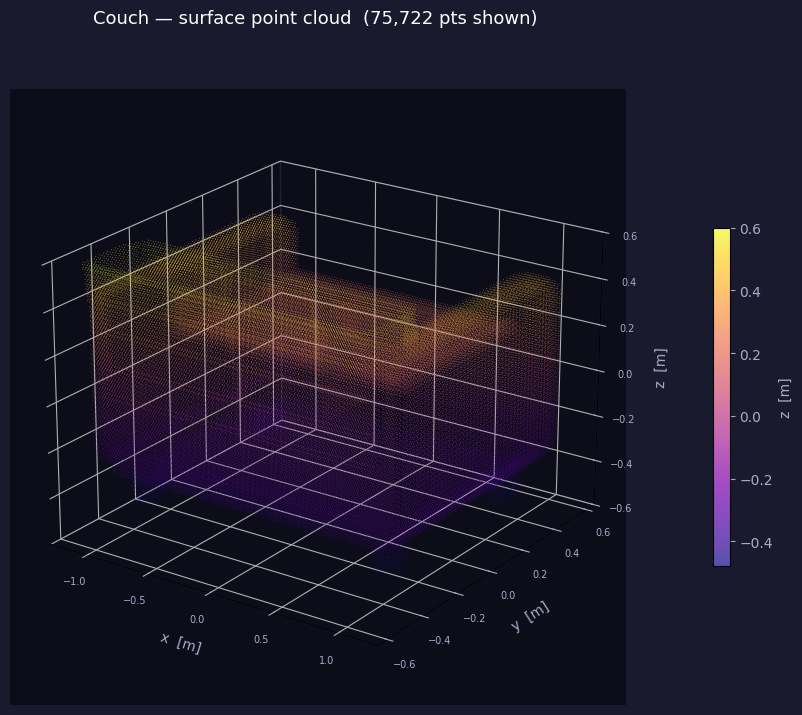

In [2]:
"""
couch.py — A procedural couch built with SPOMSO (Signed Distance Functions)
============================================================================
Run:
    python couch.py

Outputs:
    • Three orthographic cross-section views (front, side, top)
    • A 3D scatter plot of the surface point cloud
    • couch_surface.npy  — the point cloud saved to disk
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from spomso.cores.helper_functions import generate_grid, smarter_reshape
from spomso.cores.post_processing  import hard_binarization
from spomso.cores.geom_3d          import Box, Cylinder
from spomso.cores.combine          import CombineGeometry

# ── 1. Grid ────────────────────────────────────────────────────────────────────
CO_SIZE       = (2.6, 1.3, 1.2)
CO_RESOLUTION = (130, 65, 60)

coor, co_res_new = generate_grid(CO_SIZE, CO_RESOLUTION)
dx = CO_SIZE[0] / CO_RESOLUTION[0]

union = CombineGeometry("UNION")

# ── 2. Base frame ─────────────────────────────────────────────────────────────
base_frame = Box(2.10, 0.82, 0.08)
base_frame.rounding(0.03)
base_frame.move((0.0, 0.0, -0.265))

# ── 3. Legs ───────────────────────────────────────────────────────────────────
leg_positions = [
    ( 0.96,  0.34, -0.34),
    ( 0.96, -0.34, -0.34),
    (-0.96,  0.34, -0.34),
    (-0.96, -0.34, -0.34),
]
legs = []
for pos in leg_positions:
    leg = Cylinder(0.045, 0.22)
    leg.rounding(0.01)
    leg.move(pos)
    legs.append(leg)

# ── 4. Seat base ──────────────────────────────────────────────────────────────
seat_base = Box(2.10, 0.84, 0.22)
seat_base.rounding(0.04)
seat_base.move((0.0, 0.0, -0.11))

# ── 5. Three seat cushions ────────────────────────────────────────────────────
seat_cushions = []
for cx in [-0.70, 0.0, 0.70]:
    c = Box(0.62, 0.74, 0.17)
    c.rounding(0.055)
    c.move((cx, 0.04, 0.085))
    seat_cushions.append(c)

# ── 6. Back rest slab ─────────────────────────────────────────────────────────
back_slab = Box(2.10, 0.14, 0.65)
back_slab.rounding(0.05)
back_slab.move((0.0, -0.40, 0.325))
back_slab.rotate(np.deg2rad(8), (1, 0, 0))

# ── 7. Three back cushions ────────────────────────────────────────────────────
back_cushions = []
for cx in [-0.70, 0.0, 0.70]:
    bc = Box(0.60, 0.12, 0.52)
    bc.rounding(0.055)
    bc.move((cx, -0.36, 0.32))
    bc.rotate(np.deg2rad(8), (1, 0, 0))
    back_cushions.append(bc)

# ── 8. Arm rests ──────────────────────────────────────────────────────────────
arm_left  = Box(0.18, 0.82, 0.60)
arm_left.rounding(0.06)
arm_left.move(( 1.05, 0.0, 0.08))

arm_right = Box(0.18, 0.82, 0.60)
arm_right.rounding(0.06)
arm_right.move((-1.05, 0.0, 0.08))

# ── 9. Union all ──────────────────────────────────────────────────────────────
couch = union.combine(
    base_frame, *legs, seat_base,
    *seat_cushions, back_slab, *back_cushions,
    arm_left, arm_right,
)

print("Evaluating SDF on grid …")
sdf = couch.create(coor)
print("Done.")

# ── 10. Binary + point cloud ──────────────────────────────────────────────────
binary_flat = hard_binarization(sdf, 0)
binary_3d   = smarter_reshape(binary_flat, co_res_new)

surface_mask = np.abs(sdf) < dx * 1.5
surface_pts  = coor[:, surface_mask].T
np.save("couch_surface.npy", surface_pts)
print(f"Point cloud: {surface_pts.shape[0]:,} points → couch_surface.npy")

# ── 11. Cross-section figures (true proportions) ──────────────────────────────
W, D, H = CO_SIZE
scale = 4.0   # inches per metre

fig = plt.figure(
    figsize=(scale * (W + D + 0.6), scale * (H + D + 0.6)),
    facecolor="#1a1a2e"
)
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    width_ratios=[W, D], height_ratios=[H, D],
    left=0.06, right=0.97, top=0.93, bottom=0.05,
    wspace=0.10, hspace=0.15,
)
ax_front = fig.add_subplot(gs[0, 0])
ax_side  = fig.add_subplot(gs[0, 1])
ax_top   = fig.add_subplot(gs[1, 0])
ax_info  = fig.add_subplot(gs[1, 1])

mid_y = co_res_new[1] // 2
mid_x = co_res_new[0] // 2
seat_z_idx = min(int((0.10 + H/2) / H * co_res_new[2]), co_res_new[2] - 1)

for ax, data, ext, title, xl, yl, cmap in [
    (ax_front, binary_3d[:, mid_y, :].T,
     (-W/2, W/2, -H/2, H/2), "Front view  (XZ)", "x [m]", "z [m]", "Blues"),
    (ax_side,  binary_3d[mid_x, :, :].T,
     (-D/2, D/2, -H/2, H/2), "Side view  (YZ)",  "y [m]", "z [m]", "Purples"),
    (ax_top,   binary_3d[:, :, seat_z_idx].T,
     (-W/2, W/2, -D/2, D/2), "Top view  (XY, z≈+0.10 m)", "x [m]", "y [m]", "Greens"),
]:
    ax.imshow(data, cmap=cmap, origin="lower", extent=ext, aspect="equal")
    ax.set_title(title, color="white", fontsize=11, pad=6)
    ax.set_xlabel(xl, color="#aaaacc", fontsize=9)
    ax.set_ylabel(yl, color="#aaaacc", fontsize=9)
    ax.tick_params(colors="#aaaacc", labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor("#444466")
    ax.set_facecolor("#0d0d1a")

ax_info.set_facecolor("#0d0d1a")
ax_info.axis("off")
info = [
    "SPOMSO Couch",
    "─────────────────",
    f"Grid  {W:.2f} × {D:.2f} × {H:.2f} m",
    f"Res   {co_res_new[0]} × {co_res_new[1]} × {co_res_new[2]}",
    f"Voxel {dx*100:.1f} cm",
    "",
    "Parts:",
    "  • Base frame",
    "  • 4 × legs",
    "  • Seat platform",
    "  • 3 × seat cushions",
    "  • Back rest slab",
    "  • 3 × back cushions",
    "  • 2 × arm rests",
    "",
    f"Surface pts  {surface_pts.shape[0]:,}",
]
ax_info.text(0.08, 0.95, "\n".join(info),
             transform=ax_info.transAxes, va="top", ha="left",
             fontsize=9, color="#ccccee", fontfamily="monospace", linespacing=1.55)

fig.suptitle("Procedural Couch — SPOMSO SDF", color="white", fontsize=14, y=0.975)
plt.savefig("couch_views.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Saved → couch_views.png")

# ── 12. 3D point cloud scatter ────────────────────────────────────────────────
rng    = np.random.default_rng(42)
n_plot = min(80_000, surface_pts.shape[0])
idx    = rng.choice(surface_pts.shape[0], n_plot, replace=False)
pts    = surface_pts[idx]

fig3d = plt.figure(figsize=(14, 8), facecolor="#1a1a2e")
ax3d  = fig3d.add_subplot(111, projection="3d", facecolor="#0d0d1a")
sc = ax3d.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
                  c=pts[:, 2], cmap="plasma", s=0.35, alpha=0.7, linewidths=0)
ax3d.set_xlim(-W/2, W/2)
ax3d.set_ylim(-D/2, D/2)
ax3d.set_zlim(-H/2, H/2)
ax3d.set_xlabel("x  [m]", color="#aaaacc", labelpad=6)
ax3d.set_ylabel("y  [m]", color="#aaaacc", labelpad=6)
ax3d.set_zlabel("z  [m]", color="#aaaacc", labelpad=6)
ax3d.tick_params(colors="#aaaacc", labelsize=7)
ax3d.xaxis.pane.fill = ax3d.yaxis.pane.fill = ax3d.zaxis.pane.fill = False
for pane in [ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane]:
    pane.set_edgecolor("#333355")
ax3d.view_init(elev=22, azim=-55)
cb = fig3d.colorbar(sc, ax=ax3d, pad=0.08, shrink=0.55, label="z  [m]")
cb.ax.yaxis.label.set_color("#aaaacc")
cb.ax.tick_params(colors="#aaaacc")
fig3d.suptitle(f"Couch — surface point cloud  ({n_plot:,} pts shown)",
               color="white", fontsize=13)
plt.savefig("couch_pointcloud.png", dpi=150, bbox_inches="tight",
            facecolor=fig3d.get_facecolor())
print("Saved → couch_pointcloud.png")

**End response**

## Validation

The entire **object** can be visualized with the code below:

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=go.Volume(
    x=coor[0],
    y=coor[1],
    z=coor[2],
    value=binary_flat,
    isomin=0.9,
    isomax=1.0,
    opacity=1,
    surface_count=1,
))
fig.show()